# Training & Evaluation

## 1. Imports
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## 2. Load & Explore Dataset 
---

In [ ]:
# Load dataset
RUN_ID = "20260303_160907"

data_path = "../data/labeled/labeled_" + RUN_ID + ".csv"
dataframe = pd.read_csv(data_path)

# Explore
print("Total samples:", len(dataframe))
print("Total features:", len(dataframe.columns))

time_min = float(dataframe["ts_unix"].min())
time_max = float(dataframe["ts_unix"].max())
duration_hours = (time_max - time_min) / 3600.0
print("Duration (hours):", round(duration_hours, 2))

print("Shape:", dataframe.shape)
print("\nRow format:")
dataframe.head()

NameError: name 'pd' is not defined

Class Distribution:
Normal (0): 565 samples ( 78.4 % )
Anomaly (1): 156 samples ( 21.6 % )


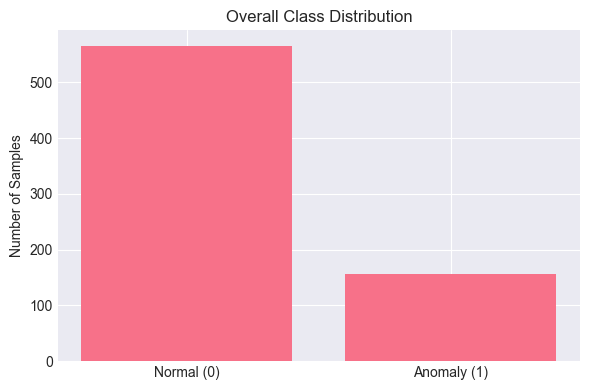

In [ ]:
# Class distribution -> count how many normal & anomaly samples exist
label_counts = dataframe["label"].value_counts()

normal_count = int(label_counts.get(0, 0))
anomaly_count = int(label_counts.get(1, 0))
total = len(dataframe)

normal_percent = (normal_count / total) * 100
anomaly_percent = (anomaly_count / total) * 100

print("Class Distribution:")
print("Normal (0):", normal_count, "samples (", round(normal_percent, 1), "% )")
print("Anomaly (1):", anomaly_count, "samples (", round(anomaly_percent, 1), "% )")

# Simple visualization
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Normal (0)", "Anomaly (1)"]
values = [normal_count, anomaly_count]
ax.bar(labels, values)
ax.set_title("Overall Class Distribution")
ax.set_ylabel("Number of Samples")
plt.tight_layout()
plt.show()

Total features: 20

Checking for possible missing values in feature columns
  - No missing values found

Visualizing feature distributions:


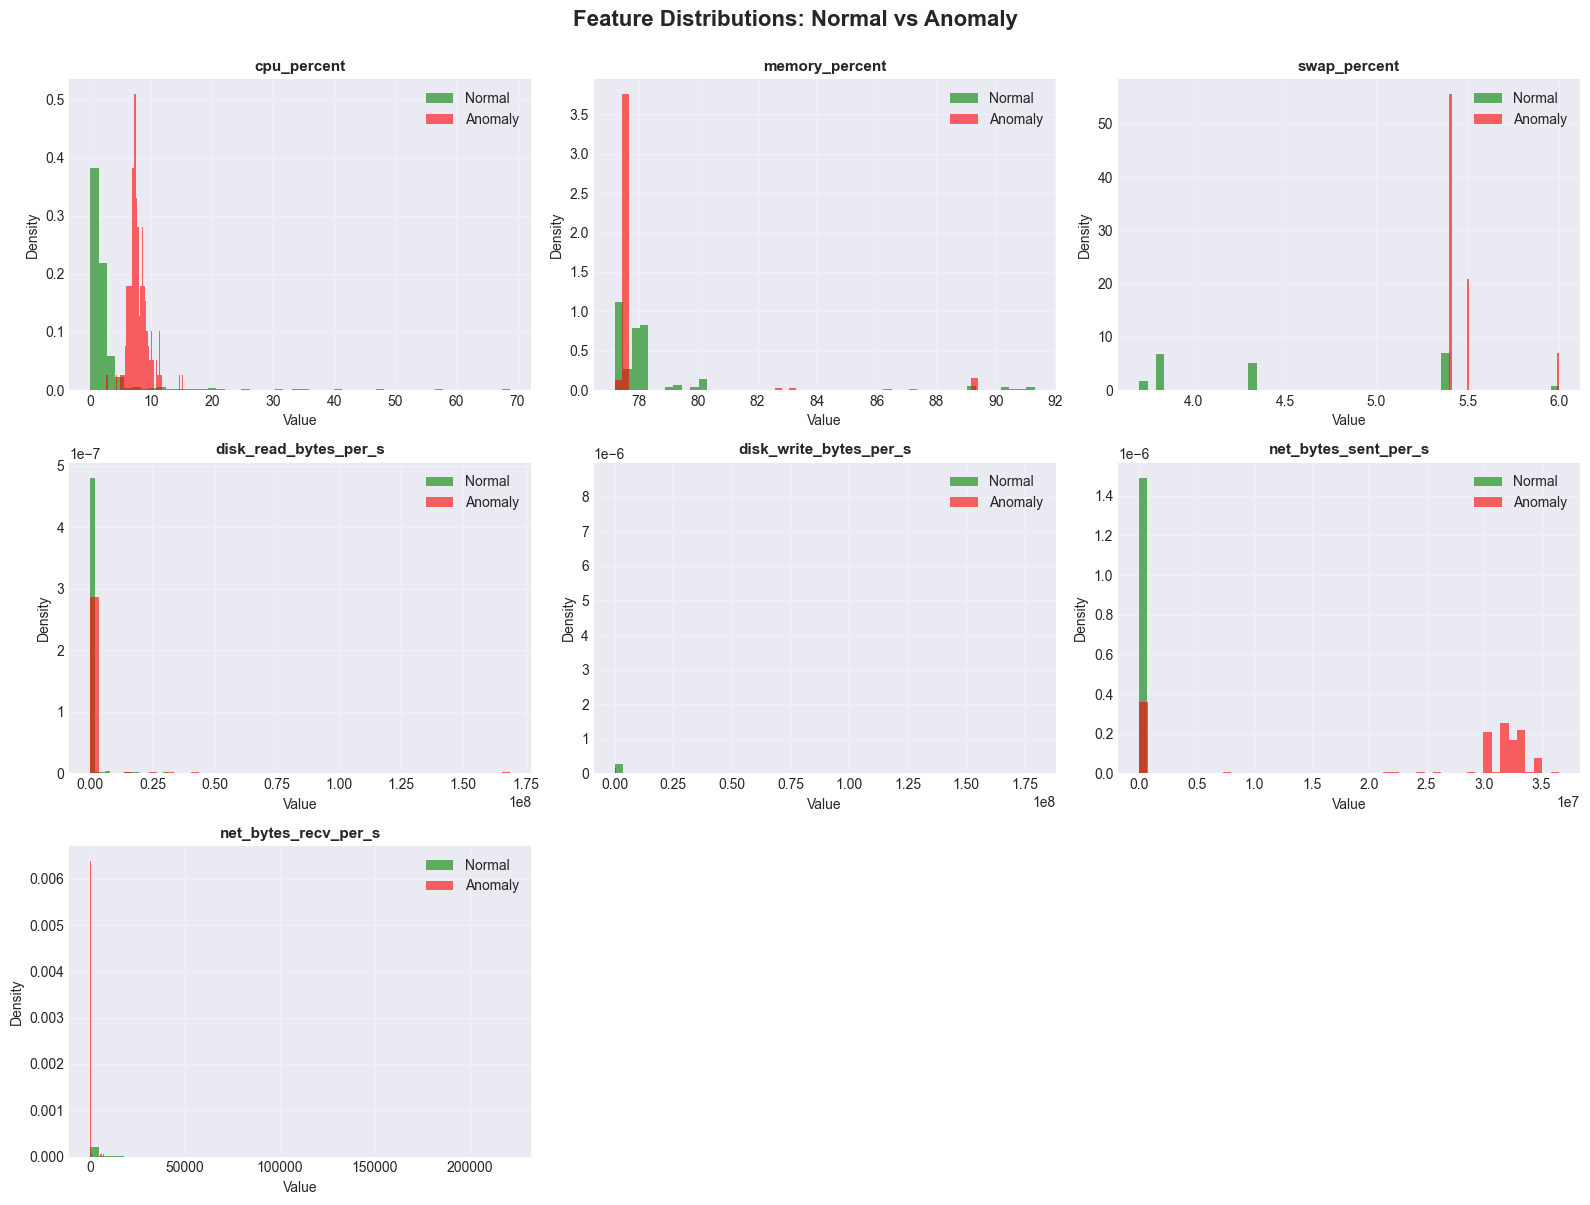

In [ ]:
# Feature columns, excluding metadata
feature_columns = [
    # CPU
    "cpu_percent",
    "cpu_percent_max",
    "cpu_percent_min",
    "cpu_frequency_mhz",
    "cpu_count",
    # Memory
    "memory_used",
    "memory_available",
    "memory_percent",
    "memory_total",
    "swap_used",
    "swap_percent",
    # Disk
    "disk_read_bytes_per_s",
    "disk_write_bytes_per_s",
    "disk_read_ops_per_s",
    "disk_write_ops_per_s",
    "disk_usage_percent_c",
    # Network
    "net_bytes_sent_per_s",
    "net_bytes_recv_per_s",
    "net_packets_sent_per_s",
    "net_packets_recv_per_s",
]

print("Total features:", len(feature_columns))

# Check for missing values
print("\nCheck for possible missing values in feature columns")
missing = dataframe[feature_columns].isnull().sum()
if missing.sum() == 0:
    print("No missing values found")
else:
    print("Missing values per feature:")
    print(missing[missing > 0])

# Feature distributions: Normal vs Anomaly
print("\nVisualizing feature distributions")
# Show only 3 most relevant signals for mimicked attack:
# 1. net_bytes_sent_per_s -> Primary signal of exfiltration
# 2. disk_read_bytes_per_s -> Attacker repeatedly reads payload file from disk
# 3. net_packets_sent_per_s -> Sustained packet flow confirming continuous TCP transmission
key_features = [
    "net_bytes_sent_per_s",
    "disk_read_bytes_per_s",
    "net_packets_sent_per_s",
]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(len(key_features)):
    feature = key_features[i]
    ax = axes[i]
    normal_values = dataframe[dataframe["label"] == 0][feature]
    anomaly_values = dataframe[dataframe["label"] == 1][feature]
    ax.hist(normal_values, bins=50, alpha=0.6, label="Normal", density=True)
    ax.hist(anomaly_values, bins=50, alpha=0.6, label="Anomaly", density=True)
    ax.set_title(feature)
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Key Feature Distributions: Normal vs Anomaly")
plt.tight_layout()
plt.show()

## 3. Preprocessing
---

In [ ]:
# Extract features and labels
X = dataframe[feature_columns]
y = dataframe["label"]

print("Feature matrix X shape:", X.shape)
print("Label vector y shape:", y.shape)

print("\nClass distribution in y:")
print(y.value_counts())

Feature matrix X: (721, 20)
Label vector y: (721,)

Class distribution in y:
label
0    565
1    156
Name: count, dtype: int64


In [ ]:
# Train / Validation / Test split

# 1st split -> (Training + Validation) & Test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2nd split: Training & Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape[0], "samples")
print("  Normal:", (y_train == 0).sum())
print("  Anomaly:", (y_train == 1).sum())

print("\nValidation set:", X_val.shape[0], "samples")
print("  Normal:", (y_val == 0).sum())
print("  Anomaly:", (y_val == 1).sum())

print("\nTest set:", X_test.shape[0], "samples")
print("  Normal:", (y_test == 0).sum())
print("  Anomaly:", (y_test == 1).sum())

# Feature scaling, converts features to mean 0 & variance 1
scaler = StandardScaler()

# Fit scaler only training data, to prevents information from other
# sets leaking into the training process
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation learned from training set
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


Training set: 460 samples (64%)
  Normal: 360
  Anomaly: 100

Validation set: 116 samples (16%)
  Normal: 91
  Anomaly: 25

Test set: 145 samples (20%)
  Normal: 114
  Anomaly: 31


## 4. Training
---

### 4.1. Supervised
---

#### 4.1.1. Logistic Regression
---

In [ ]:
# Hyperparameter grid
lr_params = {"C": [0.01, 0.1, 1.0, 10.0, 100.0], 
             "max_iter": [500, 1000, 1500]}

best_lr_score = 0
best_lr_params = None
best_lr_model = None

# Grid search using validation set
for C in lr_params["C"]:
    for max_iter in lr_params["max_iter"]:

        # Train model
        model = LogisticRegression(
            C=C,
            penalty="l2",
            max_iter=max_iter,
            random_state=42,
            class_weight="balanced",
        )

        model.fit(X_train_scaled, y_train)

        # Predict
        y_val_pred = model.predict(X_val_scaled)
        score = f1_score(y_val, y_val_pred)

        # Track best model
        if score > best_lr_score:
            best_lr_score = score
            best_lr_model = model
            best_lr_params = {"C": C, "max_iter": max_iter}

# Evaluate on test set
y_pred_lr = best_lr_model.predict(X_test_scaled) # type: ignore
y_proba_lr = best_lr_model.predict_proba(X_test_scaled)[:, 1] # type: ignore

print("\nTest Set Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("MCC:", matthews_corrcoef(y_test, y_pred_lr))

lr_model = best_lr_model

Test Set Performance:
  Accuracy:  0.9724
  Precision: 0.8857
  Recall:    1.0000
  F1-Score:  0.9394
  MCC:       0.9245


#### 4.1.1. Random Forest
---

In [ ]:
# Hyperparameter grid
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
}

best_rf_score = 0
best_rf_params = None
best_rf_model = None

# Grid search
for n_estimators in rf_params["n_estimators"]:
    for max_depth in rf_params["max_depth"]:
        for min_samples_split in rf_params["min_samples_split"]:

            # Train model
            model = RandomForestClassifier(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_split=min_samples_split,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            )

            model.fit(X_train, y_train)

            # Predict
            y_val_pred = model.predict(X_val)
            score = f1_score(y_val, y_val_pred)

            # Track best
            if score > best_rf_score:
                best_rf_score = score
                best_rf_model = model
                best_rf_params = {
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_split": min_samples_split,
                }

# Evaluate on test set
y_pred_rf = best_rf_model.predict(X_test) # type: ignore
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1] # type: ignore

print("\nTest Set Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("MCC:", matthews_corrcoef(y_test, y_pred_rf))

# Feature importance
feature_importance = pd.DataFrame(
    {"feature": feature_columns, "importance": best_rf_model.feature_importances_} # type: ignore
).sort_values("importance", ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

rf_model = best_rf_model

Test Set Performance:
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  MCC:       1.0000

Top 10 Most Important Features:
               feature  importance
       cpu_percent_max    0.272576
           cpu_percent    0.240918
      memory_available    0.094014
  net_bytes_sent_per_s    0.091565
             swap_used    0.073493
           memory_used    0.055949
          swap_percent    0.050863
        memory_percent    0.049417
net_packets_sent_per_s    0.042179
disk_write_bytes_per_s    0.005662


### 4.2. Unsupervised
---

#### 4.2.1. Isolation Forest
---

In [ ]:
# Hyperparameter grid
iso_params = {
    "contamination": [0.05, 0.1, 0.15, 0.2],
    "n_estimators": [50, 100, 200],
    "max_samples": [128, 256],
}

best_iso_score = 0
best_iso_params = None
best_iso_model = None

# Train Isolation Forest only on normal data
X_train_normal = X_train[y_train == 0]

for contamination in iso_params["contamination"]:
    for n_estimators in iso_params["n_estimators"]:
        for max_samples in iso_params["max_samples"]:

            # Train
            model = IsolationForest(
                contamination=contamination,
                n_estimators=n_estimators,
                max_samples=max_samples,
                random_state=42,
                n_jobs=-1,
            )

            model.fit(X_train_normal)

            # Predict (returns -1 for anomaly & 1 for normal)
            raw = model.predict(X_val)
            y_val_pred = np.where(raw == -1, 1, 0)
            score = f1_score(y_val, y_val_pred)

            # Track best
            if score > best_iso_score:
                best_iso_score = score
                best_iso_model = model
                best_iso_params = {
                    "contamination": contamination,
                    "n_estimators": n_estimators,
                    "max_samples": max_samples,
                }

# Evaluate on test set
raw_test = best_iso_model.predict(X_test) # type: ignore
y_pred_iso = np.where(raw_test == -1, 1, 0)

print("\nTest Set Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_iso))
print("Precision:", precision_score(y_test, y_pred_iso))
print("Recall:", recall_score(y_test, y_pred_iso))
print("F1-score:", f1_score(y_test, y_pred_iso))
print("MCC:", matthews_corrcoef(y_test, y_pred_iso))

iso_model = best_iso_model


Test Set Performance:
  Accuracy:  0.8552
  Precision: 0.6250
  Recall:    0.8065
  F1-Score:  0.7042
  MCC:       0.6191


#### 4.2.2. Local Outlier Factor
---

In [ ]:
# Hyperparameter grid
lof_params = {
    "n_neighbors": [10, 20, 35, 50],
    "contamination": [0.05, 0.1, 0.15, 0.2],
    "metric": ["minkowski"],
}

best_lof_score = 0
best_lof_model = None
best_lof_params = None

# Train on NORMAL behaviour only (scaled)
X_train_normal_scaled = X_train_scaled[y_train == 0]

for n_neighbors in lof_params["n_neighbors"]:
    for contamination in lof_params["contamination"]:
        for metric in lof_params["metric"]:

            # Train
            model = LocalOutlierFactor(
                n_neighbors=n_neighbors,
                contamination=contamination,
                metric=metric,
                novelty=True,
                n_jobs=-1,
            )

            model.fit(X_train_normal_scaled)

            # Predict (returns -1 for anomaly & 1 for normal)
            raw = model.predict(X_val_scaled)
            y_val_pred = np.where(raw == -1, 1, 0)

            score = f1_score(y_val, y_val_pred)

            if score > best_lof_score:
                best_lof_score = score
                best_lof_model = model
                best_lof_params = {
                    "n_neighbors": n_neighbors,
                    "contamination": contamination,
                    "metric": metric,
                }

# Evaluate on test set
raw_test = best_lof_model.predict(X_test_scaled) # type: ignore
y_pred_lof = np.where(raw_test == -1, 1, 0)

print("\nTest Set Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lof))
print("Precision:", precision_score(y_test, y_pred_lof))
print("Recall:", recall_score(y_test, y_pred_lof))
print("F1-score:", f1_score(y_test, y_pred_lof))
print("MCC:", matthews_corrcoef(y_test, y_pred_lof))

lof_model = best_lof_model


Test Set Performance:
  Accuracy:  0.8621
  Precision: 0.6078
  Recall:    1.0000
  F1-Score:  0.7561
  MCC:       0.7080


## 5. Comparison
---

Comparison of models:

              Model         Type  Accuracy  Precision   Recall  F1-Score
Logistic Regression   Supervised  0.972414   0.885714 1.000000  0.939394
      Random Forest   Supervised  1.000000   1.000000 1.000000  1.000000
   Isolation Forest Unsupervised  0.855172   0.625000 0.806452  0.704225
      One-Class SVM Unsupervised  0.862069   0.607843 1.000000  0.756098


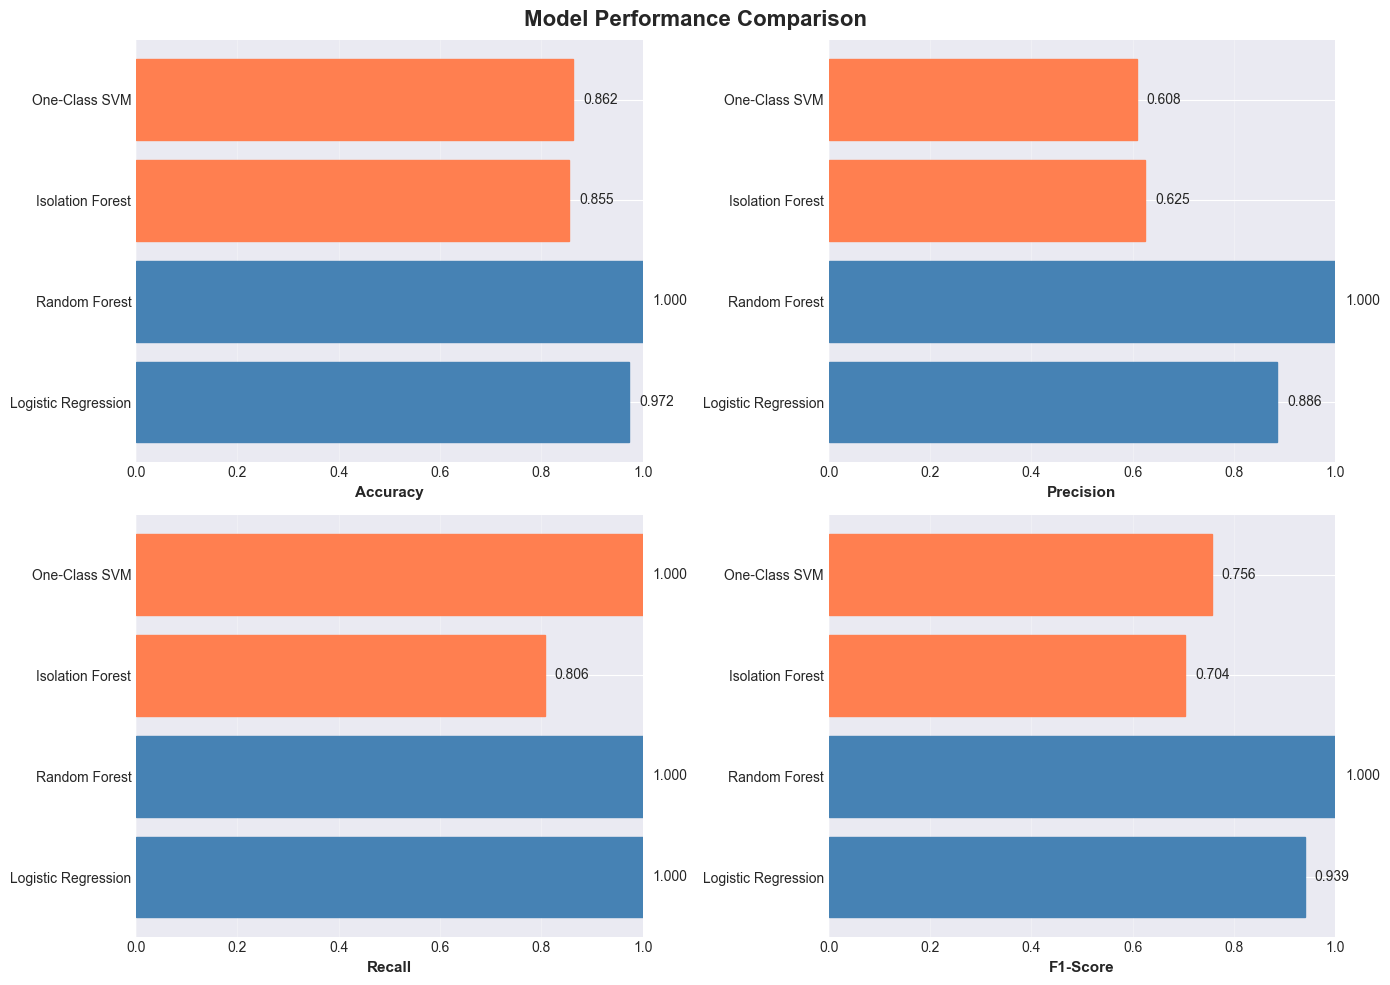

In [ ]:
results = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "type": "Supervised",
            "accuracy": accuracy_score(y_test, y_pred_lr),
            "precision": precision_score(y_test, y_pred_lr),
            "recall": recall_score(y_test, y_pred_lr),
            "f1": f1_score(y_test, y_pred_lr),
        },
        {
            "model": "Random Forest",
            "type": "Supervised",
            "accuracy": accuracy_score(y_test, y_pred_rf),
            "precision": precision_score(y_test, y_pred_rf),
            "recall": recall_score(y_test, y_pred_rf),
            "f1": f1_score(y_test, y_pred_rf),
        },
        {
            "model": "Isolation Forest",
            "type": "Unsupervised",
            "accuracy": accuracy_score(y_test, y_pred_iso),
            "precision": precision_score(y_test, y_pred_iso),
            "recall": recall_score(y_test, y_pred_iso),
            "f1": f1_score(y_test, y_pred_iso),
        },
        {
            "model": "Local Outlier Factor",
            "type": "Unsupervised",
            "accuracy": accuracy_score(y_test, y_pred_lof),
            "precision": precision_score(y_test, y_pred_lof),
            "recall": recall_score(y_test, y_pred_lof),
            "f1": f1_score(y_test, y_pred_lof),
        },
    ]
)

print("Comparison of models:\n")
print(results.sort_values("f1", ascending=False).to_string(index=False))

# Simple visualization: one plot per metric
metrics = ["accuracy", "precision", "recall", "f1"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i in range(len(metrics)):
    metric = metrics[i]
    ax = axes[i]
    ax.barh(results["model"], results[metric])
    ax.set_title(metric)
    ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

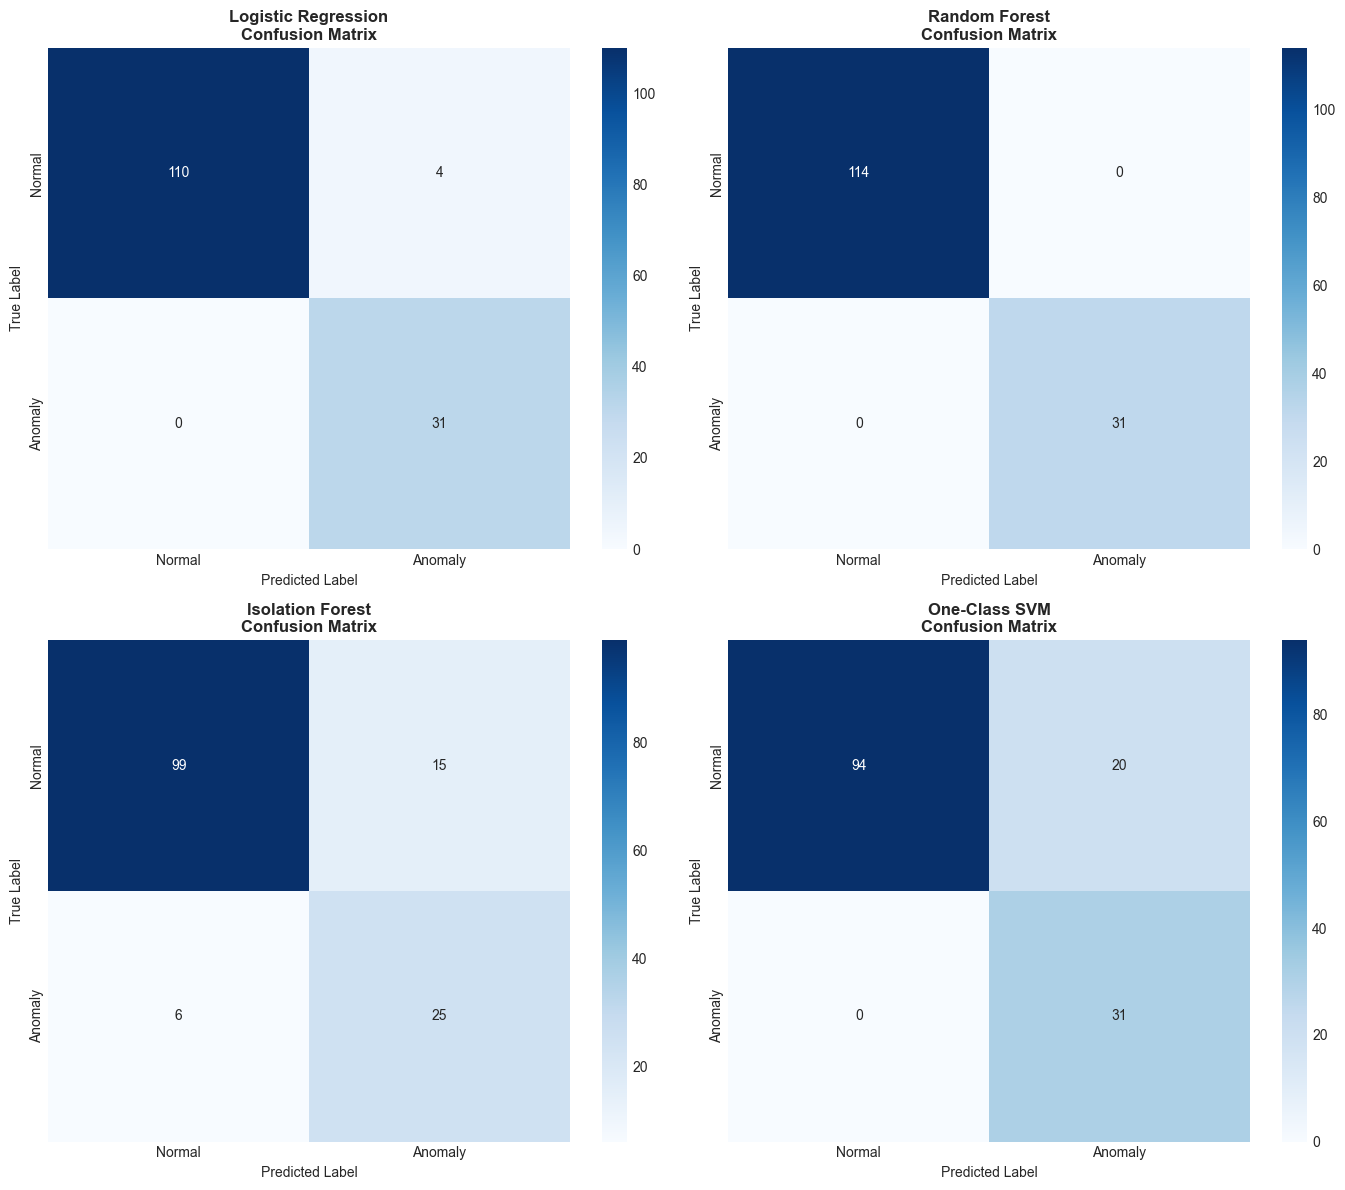

In [ ]:
# Confusion matrices for each model
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("Isolation Forest", y_pred_iso),
    ("Local Outlier Factor", y_pred_lof),
]

for i in range(len(models)):
    name, y_pred = models[i]
    ax = axes[i // 2, i % 2]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["Normal", "Anomaly"],
        yticklabels=["Normal", "Anomaly"],
    )

    ax.set_title(name + " Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## 6. Best Model
--- 

In [ ]:
# Select best model based on F1 (balance between precision and recall)
best_idx = results["f1"].idxmax()
best_model_name = results.loc[best_idx, "model"]
best_f1 = results.loc[best_idx, "f1"]

print("Best Model:", best_model_name, "(F1 =", round(best_f1, 1), ")") # type: ignore

# Map model name to the trained model object
model_map = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Isolation Forest": iso_model,
    "Local Outlier Factor": lof_model,
}

best_model = model_map[best_model_name] # type: ignore

# Map model name to its test predictions
pred_map = {
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "Isolation Forest": y_pred_iso,
    "Local Outlier Factor": y_pred_lof,
}

y_pred_best = pred_map[best_model_name] # type: ignore

print(classification_report(y_test, y_pred_best, target_names=["Normal", "Anomaly"]))

Best Model: Random Forest (F1-Score - 1.0000)
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       114
     Anomaly       1.00      1.00      1.00        31

    accuracy                           1.00       145
   macro avg       1.00      1.00      1.00       145
weighted avg       1.00      1.00      1.00       145



In [ ]:
# Save best model
model_path = "../models/best_model_" + RUN_ID + ".pkl"
scaler_path = "../models/scaler_" + RUN_ID + ".pkl"
features_path = "../models/feature_cols_" + RUN_ID + ".pkl"

os.makedirs("../models", exist_ok=True)

# Save trained model
with open(model_path, "wb") as file:
    pickle.dump(best_model, file)

# Save scaler (needed for models that require scaling)
with open(scaler_path, "wb") as file:
    pickle.dump(scaler, file)

# Save feature column order
with open(features_path, "wb") as file:
    pickle.dump(feature_columns, file)

print("Saved")